In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# List of files
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_data = []

for country in countries:
    temp_df = pd.read_csv(f"../Data/{country}.csv")
    temp_df['Country'] = country.capitalize() # Add country name column
    all_data.append(temp_df)

# Combine into one big DataFrame
df = pd.concat(all_data, ignore_index=True)
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [36]:
# Replace -999 with NaN (Not a Number)
df.replace(-999, np.nan, inplace=True)

# Check how many missing values we have now
print(df.isnull().sum())


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [37]:
# Convert to datetime
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')

# Remove the old columns to keep it clean
df.drop(['YEAR', 'DOY'], axis=1, inplace=True)


In [38]:
# Get general stats
print(df.describe())

# See average temperature per country
print(df.groupby('Country')['T2M'].mean())


                T2M       T2M_MAX       T2M_MIN     T2M_RANGE   PRECTOTCORR  \
count  20540.000000  20540.000000  20540.000000  20540.000000  20540.000000   
mean      23.742891     29.177993     19.266763      9.911230      2.740000   
min       10.030000     15.650000      1.170000      0.940000      0.000000   
25%       19.480000     26.700000     13.530000      4.380000      0.010000   
50%       25.210000     28.720000     21.960000     10.190000      0.390000   
75%       27.540000     30.710000     25.240000     14.810000      2.720000   
max       37.990000     45.960000     32.170000     23.240000    166.100000   
std        5.357470      5.125534      6.507759      5.516419      6.096451   

               RH2M          WS2M      WS2M_MAX            PS          QV2M  \
count  20540.000000  20540.000000  20540.000000  20540.000000  20540.000000   
mean      65.595643      2.969704      4.240090     91.747295     12.819402   
min        4.690000      0.460000      0.790000    

In [39]:

print(df.columns)
print(df.head())


Index(['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M',
       'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date'],
      dtype='object')
     T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  WS2M_MAX  \
0  11.73    22.75     3.44      19.31          0.0  41.79  2.73      5.07   
1  12.30    24.01     4.09      19.92          0.0  33.29  2.39      4.19   
2  12.49    24.17     3.97      20.20          0.0  33.83  1.77      2.76   
3  14.08    23.78     6.90      16.88          0.0  38.84  0.87      1.28   
4  14.06    23.15     7.32      15.83          0.0  47.07  1.34      2.14   

      PS  QV2M   Country       Date  
0  77.13  4.00  Ethiopia 2015-01-01  
1  77.14  3.35  Ethiopia 2015-01-02  
2  77.11  3.43  Ethiopia 2015-01-03  
3  77.07  4.60  Ethiopia 2015-01-04  
4  77.01  5.58  Ethiopia 2015-01-05  


In [40]:
if 'Month' not in df.columns:
    df['Month'] = df['Date'].dt.month


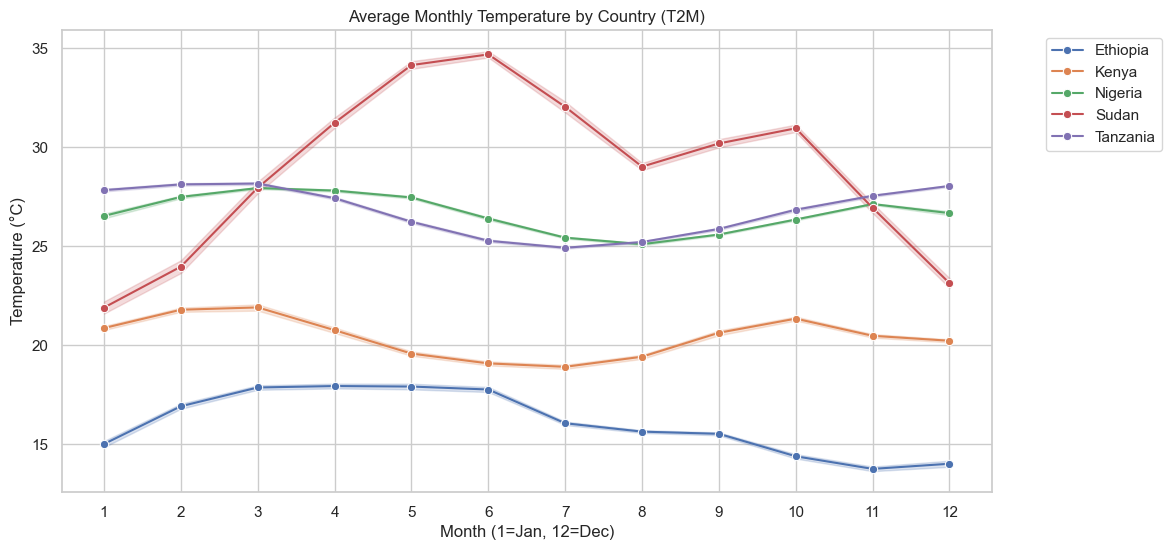

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='Month', y='T2M', hue='Country', marker='o')

plt.title('Average Monthly Temperature by Country (T2M)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13)) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


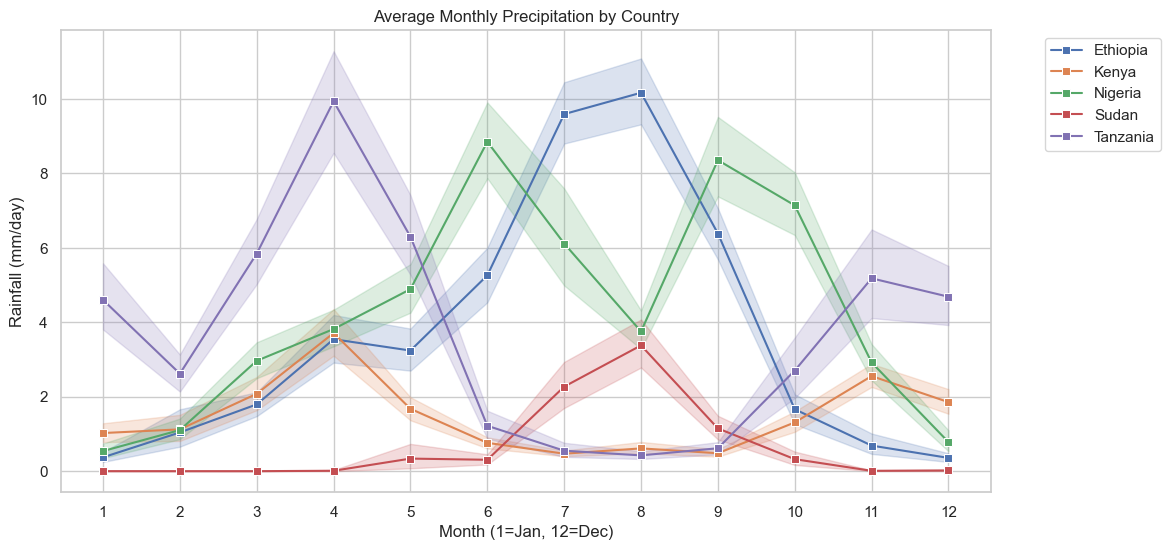

In [42]:
plt.figure(figsize=(12, 6))


sns.lineplot(data=df, x='Month', y='PRECTOTCORR', hue='Country', marker='s')

plt.title('Average Monthly Precipitation by Country')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Rainfall (mm/day)')
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


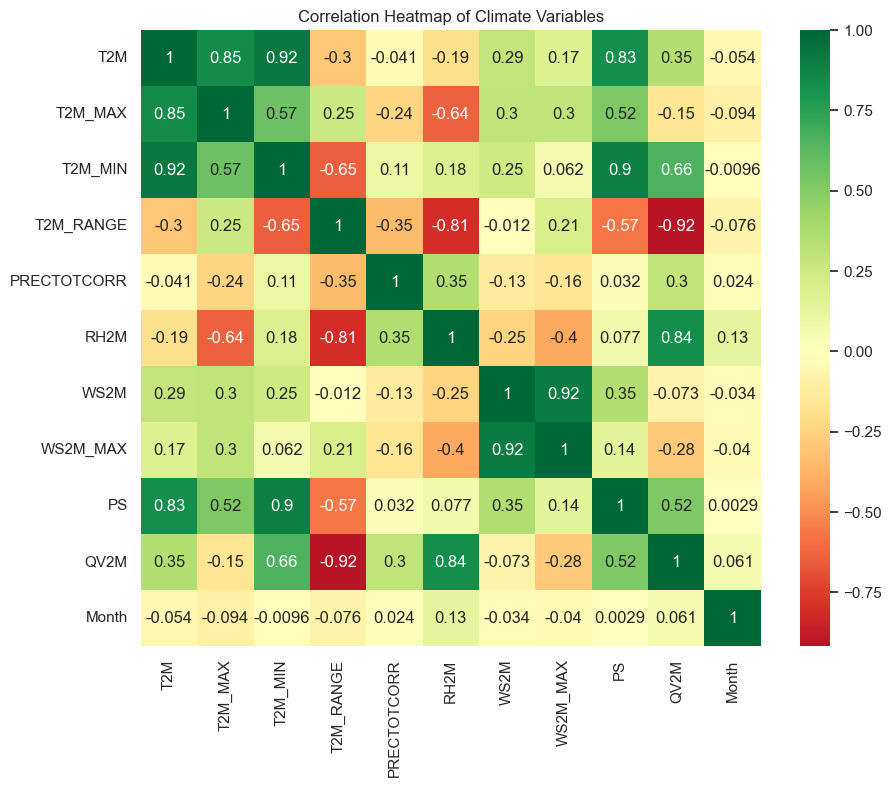

In [43]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap of Climate Variables')
plt.show()


In [44]:
duplicates = df.duplicated().sum()
print(f"duplicates: {duplicates}")


if duplicates > 0:
    df.drop_duplicates(inplace=True)


duplicates: 0


In [45]:
missing_pct = (df.isnull().sum() / len(df)) * 100
print("lost data (%):")
print(missing_pct)


lost data (%):
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64
